In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

img1 = cv2.imread("data/dog_backpack.jpg")
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.imread("data/watermark_no_copy.png")
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# The 2 images are of different shapes
print(img1.shape)
print(img2.shape)

(1401, 934, 3)
(1280, 1277, 3)


In [2]:
# Blending images of the same size:
# - Resize both images

img1 = cv2.resize(img1, (1200, 1200))
img2 = cv2.resize(img2, (1200, 1200))

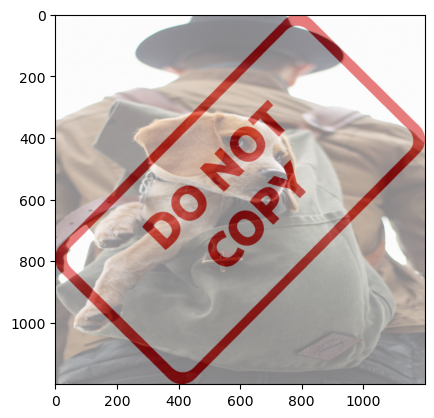

In [17]:
# To blend, do a weighted average for pixels from both images
# Aplha --> Weight for image 1
# Beta --> Weight for image 2
# Gamma --> Optional weight
blended_image = cv2.addWeighted(src1 = img1, alpha = 0.5, src2 = img2, beta = 0.5, gamma = 0)
# addWeighted works ONLY if the images are of the same size
plt.imshow(blended_image)

(1280, 1277, 3)
(400, 400, 3)


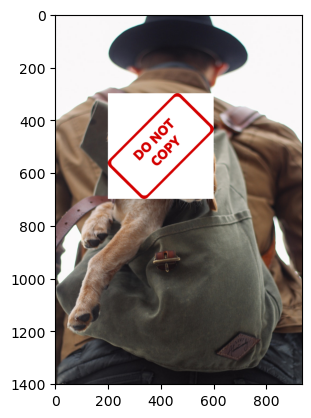

In [3]:
# Overlay small image on top of a larger image (No blending) - Numpy reassignment
img_large = cv2.imread("data/dog_backpack.jpg")
img_large = cv2.cvtColor(img_large, cv2.COLOR_BGR2RGB)
img_small = cv2.imread("data/watermark_no_copy.png")
img_small = cv2.cvtColor(img_small, cv2.COLOR_BGR2RGB)
print(img_small.shape)
# Make img2 much smaller
img_small = cv2.resize(img_small, (400, 400))
print(img_small.shape)

# Set the position for overlay (Region of Interest - ROI)
x_offset = 200
y_offset = 300
x_end = x_offset + img_small.shape[1]
y_end = y_offset + img_small.shape[0]

img_large[y_offset:y_end, x_offset:x_end] = img_small
plt.imshow(img_large)

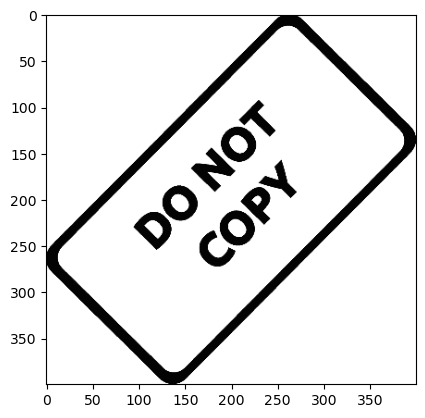

In [4]:
# To remove the white background and just copy the watermark
# 1st convert img2 to grayscale version
img_small_gray = cv2.cvtColor(img_small, cv2.COLOR_RGB2GRAY)
plt.imshow(img_small_gray, cmap = "gray")

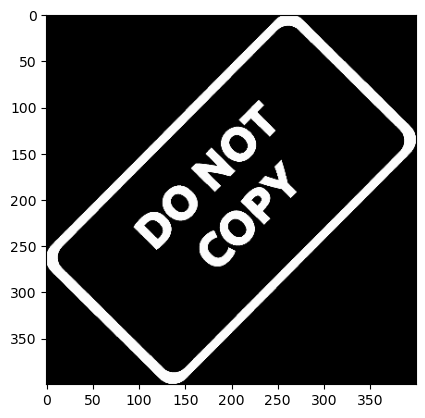

In [5]:
# The above image needs to be inversed - since the black part will be removed from the background
img_small_gray_inverse = cv2.bitwise_not(img_small_gray)
# bitwise_not calculates per-element bitwise inversion of the input

plt.imshow(img_small_gray_inverse, cmap = "gray")

(400, 400)
(400, 400, 3)
(400, 400, 3)


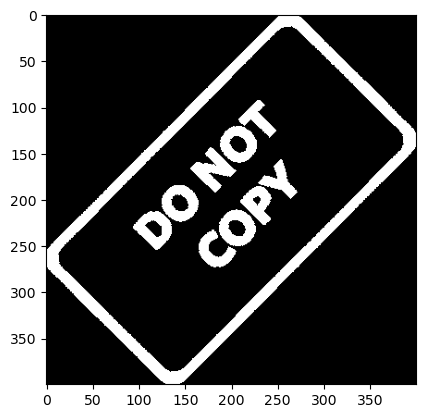

In [6]:
# Notice how the image is now 2 dimensional - 3rd (colour channel is lost)
print(img_small_gray_inverse.shape)

# Lets add the 3rd channel back
white_background = np.full(img_small.shape, 255, dtype = np.uint8)
# img_small is passed above to get the required shape
# 255 is what the shape is filled with --> 255 for all 3 channels make it white
print(white_background.shape)

# Set the background for 3 channel image
# bitwise_or uses source#1, source#2, mask
bk = cv2.bitwise_or(white_background, white_background, mask = img_small_gray_inverse)
print(bk.shape)
plt.imshow(bk)

(400, 400, 3)


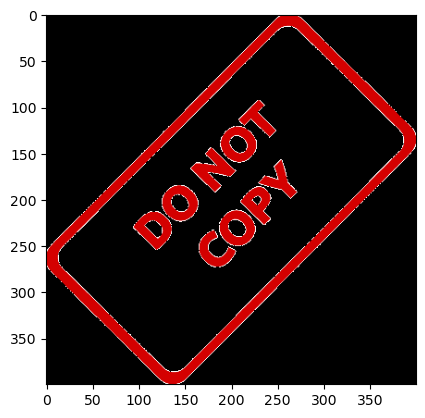

In [7]:
# Now place the original foreground image (red) and place it on top of the mask
fg = cv2.bitwise_or(img_small, img_small, mask = img_small_gray_inverse)
# Anything in white will shine through
print(fg.shape)
plt.imshow(fg)

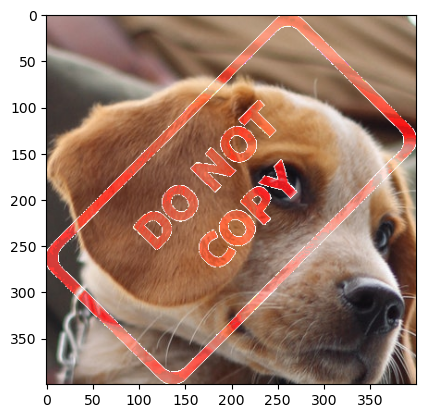

In [8]:
# Create the final roi

img_large = cv2.imread("data/dog_backpack.jpg")
img_large = cv2.cvtColor(img_large, cv2.COLOR_BGR2RGB)

# Set the position for overlay (Region of Interest - ROI)
x_offset = 200
y_offset = 300
x_end = x_offset + img_small.shape[1]
y_end = y_offset + img_small.shape[0]
roi = img_large[y_offset:y_end,x_offset:x_end]

final_roi = cv2.bitwise_or(roi,fg)
plt.imshow(final_roi)

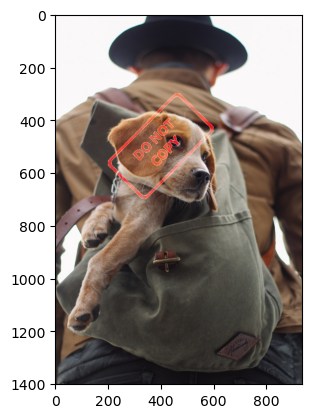

In [9]:
# Final image - including the new ROI
img_large[y_offset:y_end, x_offset:x_end] = final_roi
plt.imshow(img_large)